# Sorting the supervisors' notes: does a trained classifier beat the keyword rules?

The dashboard currently sorts notes with a **keyword lexicon** — a hand-written list of words and
phrases per category. This notebook tests a **Naive Bayes bag-of-words classifier** against it.

**The trap to avoid.** The classifier is trained on labels the lexicon produced. So on the real
notes it can only ever learn to imitate the lexicon — scoring them against each other there is
circular and proves nothing. The honest test is **60 notes written by hand in language the lexicon
was never given**, where both methods have to generalise.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))
from src.db import connect
from src.notes import (CATEGORIES, classify_all_methods, classify_lexicon,
                       normalise, train_naive_bayes)

plt.rcParams.update({"figure.figsize": (9,3.6), "axes.grid": True, "grid.alpha": .3,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 10})
pd.set_option("display.width", 200); pd.set_option("display.max_colwidth", 70)

conn = connect(Path.cwd().parent / "shifts.db")
notes = pd.read_sql("SELECT shift_id, note FROM shift_notes", conn)
notes["note"] = notes.note.fillna("")
model = train_naive_bayes(conn)

vec = model.pipeline.named_steps["countvectorizer"]
print(f"{len(notes):,} notes, {notes.note.str.lower().nunique()} distinct")
print(f"vocabulary learned: {len(vec.vocabulary_):,} words and word-pairs")

2,117 notes, 846 distinct
vocabulary learned: 1,791 words and word-pairs


/home/gideon/jem/jemx-technical-assessment/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:412: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['sixam'] not in stop_words.
  warnings.warn(


## How the text is turned into numbers

Standard scikit-learn tokenizing — the default `\b\w\w+\b` word pattern, English stop words,
unigrams plus bigrams. Pairs earn their place: *"no show"*, *"did not"* and *"signed off"* each
mean something their separate words do not.

The one custom piece is the **preprocessor**, which folds the five spellings of 6am together,
expands abbreviations, and maps Afrikaans and isiZulu stems onto the English idea they carry.
Without it each language would need its own vocabulary learned from very few examples.

In [2]:
example = "Klient het ekstra ure gevra vir stocktake, aprvd by mgr agn"
print("raw:       ", example)
print("normalised:", normalise(example))
print("tokens:    ", vec.build_analyzer()(example))

raw:        Klient het ekstra ure gevra vir stocktake, aprvd by mgr agn
normalised: client het extra hours gevra vir stocktake, aprvd by manager again
tokens:     ['client', 'het', 'extra', 'hours', 'gevra', 'vir', 'stocktake', 'aprvd', 'manager', 'client het', 'het extra', 'extra hours', 'hours gevra', 'gevra vir', 'vir stocktake', 'stocktake aprvd', 'aprvd manager']


**Add-one smoothing.** Every word gets a pretend extra count in every category, so a word never
seen alongside a category does not drive its probability to zero and veto the whole note on one
unfamiliar term.

## 1. Can the classifier learn the lexicon at all?

In [3]:
from sklearn.model_selection import cross_val_predict
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline

y = np.array([classify_lexicon(t) for t in notes.note])
pipe = make_pipeline(
    CountVectorizer(preprocessor=normalise, ngram_range=(1,2), stop_words="english"),
    MultinomialNB(alpha=1.0))
cv = cross_val_predict(pipe, notes.note.tolist(), y, cv=5)

print(f"5-fold agreement with the lexicon on the real notes: {(cv == y).mean():.1%}")
print("\nThis is a sanity check, not a result. It says the classifier can reproduce the")
print("lexicon's decisions from words alone - so anything that follows is about coverage,")
print("not about the model failing to fit.")

/home/gideon/jem/jemx-technical-assessment/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:412: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['sixam'] not in stop_words.
  warnings.warn(
/home/gideon/jem/jemx-technical-assessment/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:412: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['sixam'] not in stop_words.
  warnings.warn(
/home/gideon/jem/jemx-technical-assessment/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:412: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['sixam'] not in stop_words.
  warnings.warn(


5-fold agreement with the lexicon on the real notes: 92.9%

This is a sanity check, not a result. It says the classifier can reproduce the
lexicon's decisions from words alone - so anything that follows is about coverage,
not about the model failing to fit.


/home/gideon/jem/jemx-technical-assessment/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:412: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['sixam'] not in stop_words.
  warnings.warn(
/home/gideon/jem/jemx-technical-assessment/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:412: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['sixam'] not in stop_words.
  warnings.warn(


## 2. The real test: 60 notes the lexicon has never seen

Written by hand, one batch per category, deliberately avoiding the phrasings in the lexicon.
They include SA idiom (*"nobody rocked up"*), Afrikaans and isiZulu words not in the lexicon
(*"die aflosser het my in die steek gelaat"*, *"kulungile"*), synonyms (*"the polisher packed
up"*, *"compressor died"*), and four notes that contradict themselves.

In [4]:
hand = pd.read_csv(Path.cwd().parent / "labels/handcrafted_notes.csv")
results = classify_all_methods(conn, hand.note.tolist(), model)
results["truth"] = hand.true_category.values
results["why_hard"] = hand.why_it_is_hard.values

METHODS = ["lexicon", "naive_bayes", "hybrid"]
scores = {m: (results[m] == results.truth).mean() for m in METHODS}
for m, s in scores.items():
    print(f"  {m:12s} {s:6.1%}   ({(results[m]==results.truth).sum()}/{len(results)})")

  lexicon       13.3%   (8/60)
  naive_bayes   46.7%   (28/60)
  hybrid        50.0%   (30/60)


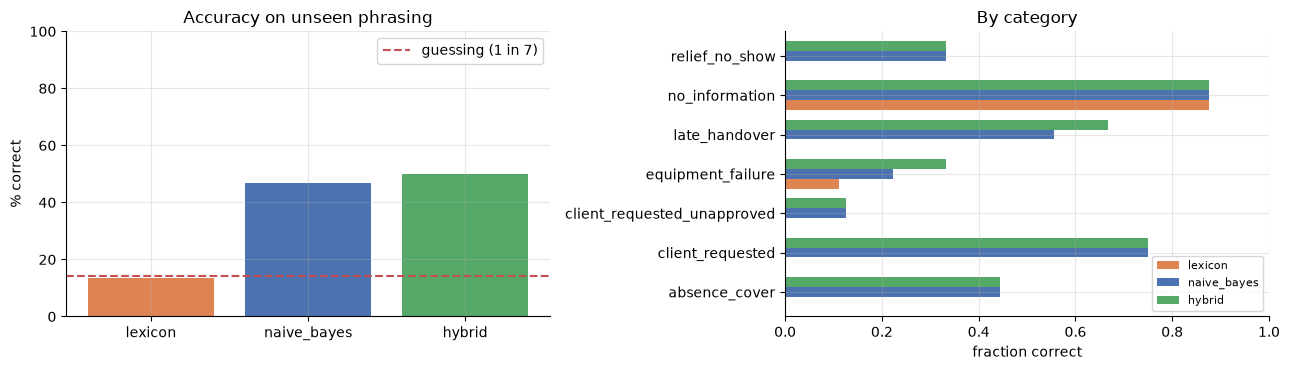

                             lexicon  naive_bayes  hybrid
category                                                 
absence_cover                   0.00         0.44    0.44
client_requested                0.00         0.75    0.75
client_requested_unapproved     0.00         0.12    0.12
equipment_failure               0.11         0.22    0.33
late_handover                   0.00         0.56    0.67
no_information                  0.88         0.88    0.88
relief_no_show                  0.00         0.33    0.33


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
ax[0].bar(list(scores), [v*100 for v in scores.values()],
          color=["#DD8452", "#4C72B0", "#55A868"])
ax[0].axhline(100/7, color="#C44E52", ls="--", label="guessing (1 in 7)")
ax[0].set(title="Accuracy on unseen phrasing", ylabel="% correct", ylim=(0,100)); ax[0].legend()

per_cat = pd.DataFrame([{"category": c, **{m: (g[m]==c).mean() for m in METHODS}}
                        for c, g in results.groupby("truth")]).set_index("category")
per_cat.plot.barh(ax=ax[1], color=["#DD8452", "#4C72B0", "#55A868"], width=.75)
ax[1].set(title="By category", xlabel="fraction correct", ylabel="", xlim=(0,1))
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print(per_cat.round(2).to_string())

**The keyword lexicon collapses.** It sorts 55 of the 60 into "nothing useful here" — not because
those notes say nothing, but because none of the words it was given appear. It is precise about
what it recognises and close to blind about everything else. On the real notes it looks excellent
only because it was built by reading those exact templates.

**Naive Bayes does better, but be careful about why.** It scores 47% against the lexicon's 13%,
and that gap is far too large to be chance. But the mechanism is not the tidy story of "it learned
what the words mean" — these notes were written to avoid the observed vocabulary, so most of them
share almost nothing with the training text. Worth measuring rather than assuming.

In [6]:
analyzer = vec.build_analyzer()
results["known_tokens"] = [[t for t in analyzer(n) if t in vec.vocabulary_] for n in results.note]
results["n_known"] = results.known_tokens.map(len)
print("known tokens per hand-written note:")
print(f"  median {results.n_known.median():.0f}, and {(results.n_known == 0).sum()} of 60 share no word at all")
print()
print("Naive Bayes accuracy by how much vocabulary the note shares:")
print(results.groupby(pd.cut(results.n_known, [-1,0,1,2,4,20]), observed=True)
      .apply(lambda g: pd.Series({"notes": len(g),
                                  "correct": (g.naive_bayes == g.truth).mean().round(2)}),
             include_groups=False).to_string())
print("two it got right, and the only word it recognised:")
for r in results[(results.naive_bayes == results.truth) & (results.n_known <= 2)].head(4).itertuples():
    print(f"  {r.note[:52]:54s} saw {r.known_tokens}")

known tokens per hand-written note:
  median 2, and 14 of 60 share no word at all

Naive Bayes accuracy by how much vocabulary the note shares:
         notes  correct
n_known                
(-1, 0]   14.0     0.50
(0, 1]    11.0     0.27
(1, 2]    16.0     0.69
(2, 4]    16.0     0.31
(4, 20]    3.0     0.67
two it got right, and the only word it recognised:
  waited past midnight for my replacement, never showe   saw ['waited', 'replacement']
  oncoming shift was a no-show                           saw ['shift']
  did both posts myself, mkhize off with flu             saw ['did', 'posts']
  stepped in for the day shift lady, death in the fami   saw ['shift', 'family']


This is the honest reading. Half the hand-written notes share zero or one word with anything the
model has seen, so it is often deciding on a single incidental term — *"water pump gave in, carried
buckets"* is scored correctly off the word **carried**, which has nothing to do with equipment.
Some of the 47% is luck.

What survives the caveat is the *direction*, and it is not subtle: the lexicon sorts **55 of 60**
into "nothing useful here", because none of its keywords appear. Naive Bayes at least has a
vocabulary broad enough to have an opinion. That difference is real and would not reverse with a
better test set — but "47%" should be read as "roughly half, on notes deliberately chosen to be
hard", not as a production accuracy figure.

## 3. Where each one breaks

In [7]:
print("LEXICON right, Naive Bayes wrong:")
for r in results[(results.lexicon==results.truth)&(results.naive_bayes!=results.truth)].itertuples():
    print(f"  [{r.truth}] {r.note[:62]}\n      NB said {r.naive_bayes}")
print("\nNAIVE BAYES right, lexicon wrong:", 
      ((results.naive_bayes==results.truth)&(results.lexicon!=results.truth)).sum(), "notes, e.g.")
for r in results[(results.naive_bayes==results.truth)&(results.lexicon!=results.truth)].head(5).itertuples():
    print(f"  [{r.truth}] {r.note[:62]}\n      lexicon said {r.lexicon}")

LEXICON right, Naive Bayes wrong:
  [equipment_failure] management approved the overtime though the real story is the 
      NB said client_requested

NAIVE BAYES right, lexicon wrong: 21 notes, e.g.
  [relief_no_show] waited past midnight for my replacement, never showed up
      lexicon said no_information
  [relief_no_show] graveyard guy phoned to say he wasnt coming so i stayed
      lexicon said no_information
  [relief_no_show] oncoming shift was a no-show
      lexicon said no_information
  [absence_cover] did both posts myself, mkhize off with flu
      lexicon said no_information
  [absence_cover] stepped in for the day shift lady, death in the family
      lexicon said no_information


In [8]:
contra = results[results.why_hard == "contrastive"]
print("The four self-contradicting notes — the ones that decide whether overtime")
print("is billed to the client or counted as a preventable failure:\n")
for r in contra.itertuples():
    print(f"  {r.note}")
    print(f"    truth={r.truth}  lexicon={r.lexicon}  naive_bayes={r.naive_bayes}  hybrid={r.hybrid}\n")

The four self-contradicting notes — the ones that decide whether overtime
is billed to the client or counted as a preventable failure:

  tenant signed the extra hours but honestly it was because nobody relieved me
    truth=relief_no_show  lexicon=no_information  naive_bayes=client_requested  hybrid=no_information

  management approved the overtime though the real story is the polisher broke
    truth=equipment_failure  lexicon=equipment_failure  naive_bayes=client_requested  hybrid=equipment_failure

  billed to the client but truthfully we were short-staffed all night
    truth=absence_cover  lexicon=client_requested  naive_bayes=client_requested  hybrid=no_information

  client put it in writing however the actual cause was the late changeover
    truth=late_handover  lexicon=client_requested  naive_bayes=client_requested  hybrid=late_handover



**This is the one place bag-of-words cannot win, and it matters most.** *"Management approved the
overtime though the real story is the polisher broke"* contains *approved* and *management*, so the
word counts point firmly at client-requested. Naive Bayes has no concept of word order and calls
all four client-requested.

The lexicon can handle it, because it has an explicit rule: if a note contains a contrastive marker
(*but*, *however*, *real reason*), only the clause after it counts.

Getting these wrong moves cost from the "somebody should fix this" pile into the "client pays,
fine" pile — the exact mistake that hides an operational problem.

So the hybrid takes the contrastive rule from the lexicon and hands the *clause after the marker*
to Naive Bayes. It gets two of the four outright, and — this is the part that matters — the other
two come back as **"no reason recorded"** rather than as client-requested. On a self-contradicting
note it will now either be right or admit it does not know. It will not quietly bill a preventable
failure to the client.

## 4. What the classifier actually learned

Worth looking at, because it is the check that the model latched onto meaning rather than an
accident of the data.

In [9]:
nb = model.pipeline.named_steps["multinomialnb"]
vocab = np.array(vec.get_feature_names_out())
top = {}
for i, cls in enumerate(nb.classes_):
    others = np.delete(nb.feature_log_prob_, i, axis=0).max(axis=0)
    top[cls] = vocab[np.argsort(nb.feature_log_prob_[i] - others)[-8:]][::-1]
print(pd.DataFrame(top).to_string(index=False))

    absence_cover  client_requested client_requested_unapproved equipment_failure late_handover no_information relief_no_show
          covered             asked                 know office              hand      handover          quiet         relief
           booked      client asked                   dont know           machine           min         report relief arrived
      booked sick        management                  sixam dont             floor          keys           fine           room
 additional cover centre management                        dont         generator       missing    quiet shift        control
namhlanje covered             event                   says stay             broke  keys missing            ntr   control room
            posts            patrol                   stay till             fault     late keys          sharp         coming
     covered yena      extra patrol             office approved           monitor  min handover           good  relief

Read down the columns: these are the words most distinctive of each category, and they are the
words a supervisor would actually use. Nothing spurious, no site codes or names leaking in.

## 5. Does it help on the real notes?

In [10]:
real = pd.read_sql("SELECT note FROM shift_notes", conn).note.fillna("")
both = classify_all_methods(conn, real.tolist(), model)
rescued = both[(both.lexicon == "no_information") & (both.hybrid != "no_information")]
print(f"agreement with the lexicon on all {len(both):,} real notes: "
      f"{(both.hybrid == both.lexicon).mean():.1%}  (so nothing regressed)")
print(f"notes the lexicon gave up on that the hybrid recovered: {len(rescued)}")
print()
for r in rescued.head(8).itertuples():
    print(f"  -> {r.hybrid:19s} {r.note[:60]}")

agreement with the lexicon on all 2,117 real notes: 99.4%  (so nothing regressed)
notes the lexicon gave up on that the hybrid recovered: 12

  -> absence_cover       Covreed for Mabaso agn - 3rd time this month
  -> relief_no_show      reliief only arrived 06:00, stayed until then
  -> absence_cover       uPillay akezanga namhlanje, nimele yena !
  -> equipment_failure   gate motoor failed, manned it by hadn till 6
  -> relief_no_show      no relif. stayed. someone must please sort the roster
  -> relief_no_show      no repacement sent, ngicela sort this out
  -> relief_no_show      relef only arrived 6am, stayed until then..
  -> absence_cover       usithole akezanga namhlanje, ngimeel yena


Every one is a typo the keyword list could not survive — *Covreed*, *reliief*, *no relif*,
*no repacement*, *gate motoor ... by hadn*. Small in number, but these are exactly the notes the
brief warned about: typed at 3am on a phone with cracked glass. The classifier reads them because
it learned that those letter patterns keep company with those causes.

## 6. What goes into production

In [11]:
print(f"{'method':<14}{'unseen phrasing':>18}{'contrastive notes':>20}")
for m in METHODS:
    print(f"{m:<14}{(results[m]==results.truth).mean():>17.1%}"
          f"{(contra[m]==contra.truth).sum():>15}/4")

method           unseen phrasing   contrastive notes
lexicon                   13.3%              1/4
naive_bayes               46.7%              0/4
hybrid                    50.0%              2/4


**The hybrid ships**, and it is not a fudge — the two methods fail in genuinely different places.

The lexicon runs first, because its rules encode something a bag of words cannot represent: that
in *"client signed the hours but the real reason was the relief"*, the clause after *but* is the
one that counts. Whatever the lexicon does not recognise falls through to Naive Bayes, which is
where unfamiliar phrasing lands. If a note contains no word the model has ever seen, it abstains
rather than guessing — without that, *"zzz"* came back as absence cover, because with no evidence
Naive Bayes quietly returns whichever class was largest in training.

**Honest limits of this test.** I wrote both the lexicon and these 60 notes, so I could have
written examples that flatter either. I tried to avoid it by using synonyms and languages the
lexicon has no entry for, but this is not a substitute for labels from someone else. Sixty notes
is also a small sample — the difference between 13% and 47% is far too large to be chance, but the
per-category figures rest on eight or nine notes each and should be read as direction, not
measurement.

**And a real result worth stating plainly:** on notes drawn from the templates that actually appear
in this dataset, the lexicon is excellent. It only collapses on phrasing that does not occur in the
data we have. If next week's export looks like this week's, the lexicon alone would be fine. The
hybrid is insurance against it not doing so — supervisors change, sites change, and nothing about
the keyword list would tell us it had stopped working.